<a href="https://colab.research.google.com/github/doubletran/resnet14-cifar10-pytorch/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms


## Datasets and Dataloaders

In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


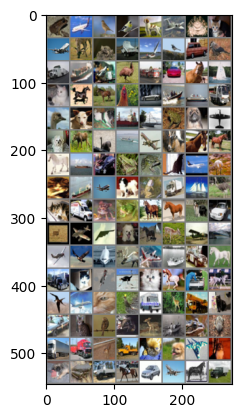

frog  plane bird  bird  dog   plane frog  cat   plane deer  frog  truck ship  bird  car   bird  truck ship  bird  bird  truck car   horse ship  cat   horse horse bird  car   ship  ship  truck bird  dog   dog   ship  ship  frog  dog   plane dog   deer  bird  ship  plane deer  horse horse horse ship  car   frog  frog  cat   plane bird  cat   ship  plane dog   frog  truck ship  bird  cat   truck dog   frog  horse horse dog   car   deer  plane plane dog   horse deer  plane ship  plane bird  plane deer  plane ship  car   horse truck cat   plane bird  cat   horse car   horse bird  plane cat   bird  truck deer  truck cat   car   cat   bird  cat   deer  ship  frog  bird  truck truck deer  truck dog   dog   plane cat   dog   frog  truck horse car   plane horse truck


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

## Layers and Models

In [ ]:


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [6]:
class ResBlock(nn.Module):
    def __init__(self,inplanes: int,planes: int, stride: int = 1, downsampling:bool =False,  padding:int = 1) -> None:
        super().__init__()
        self.conv1= nn.Conv2d(inplanes,planes,kernel_size=3,
                                        stride=stride,padding=padding,bias=False)

        self.bn1 = nn.BatchNorm2d(planes)
        #self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes,planes,kernel_size=3,
                              stride=1,padding=padding,bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity()

        if stride != 1 or inplanes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )
    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        #out = self.relu1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out +=self.shortcut(x)
        out = self.relu2(out)

        return out

In [4]:
class MyResNet(nn.Module):

  def __init__(self,inplanes: int, classes: int,) -> None:
    num_filters=16
    super().__init__()
    self.conv1 = nn.Conv2d(inplanes,num_filters,kernel_size=3, padding=1, bias=True)
    inplanes=32
    self.layer1 = self.make_layer(16, 16, 1)
    self.layer2 = self.make_layer(16, 32, 2)
    self.layer3 = self.make_layer(32, 64, 2)
    self.globalpool = nn.AvgPool2d((8, 8))
  def make_layer(self, inplanes, planes, stride):
    n = 2
    blocks = [ResBlock(inplanes, planes, stride), ResBlock(planes, planes, 1)]

    return nn.Sequential(*blocks)


  def forward(self, x: Tensor) -> Tensor:
    out = self.conv1(x)
    out = F.relu(out)
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    #out = self.conv1x1(out)
    out = self.globalpool(out)
    return out.squeeze()

In [7]:
model = MyResNet(3, 10)
print(model)

MyResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (shortcut): Identity()
    )
    (1): ResBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
     

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualizeBatch(x_batch,pred, num=10):
  f, axs = plt.subplots(num, 2, figsize=(14,6*num))
  for i in range(0,num):
    axs[i,0].imshow(x_batch[i,:,:].squeeze(), cmap='gray')
    axs[i,1].bar(list(range(10)),pred[i,:], label=list(range(10)))

  return f

## Training

In [8]:
import wandb

wandb.login()


device = torch.device('cuda')

model.to(device)


config = {'epochs': 20, 'lr': 3e-3}
iter = 0
with wandb.init(config = config) as run:

    wandb.define_metric("train/iter_loss", step_metric="global_step")
    wandb.define_metric("val/epoch_loss", step_metric="epoch")
    wandb.define_metric("val/epoch_accuracy", step_metric="epoch")
    wandb.define_metric("val/epoch_err", step_metric="epoch")

    optimizer = torch.optim.SGD(model.parameters(), lr=run.config['lr'], weight_decay=0.0)
    criterion = torch.nn.CrossEntropyLoss()
    for i in range(run.config['epochs']):
        model.train()
        print("Epoch {}".format(i))
        for j,input in enumerate(trainloader,0):
            iter+=1



            x = input[0].to(device)
            y = input[1].to(device)

            if iter == 0:
                image = wandb.Image(x[0,:,:,:])
                run.log({"example": image})

            out = model(x)
            loss = criterion(out,y)
            model.conv1.weight.requires_grad = False

            model.zero_grad()
            loss.backward()

            optimizer.step()

            _, predicted = torch.max(out.data, 1)
            correct = (predicted == y).float().mean().item()


            run.log({"train/train_loss": loss.item(), "train/train_accuracy": correct}, step = iter)



        model.eval()
        running_loss = 0
        running_acc = 0
        running_err = 0
        for j,input in enumerate(testloader,0):

             x = input[0].to(device)
             y = input[1].to(device)

             out = model(x)
             loss = criterion(out,y)

             _, predicted = torch.max(out.data, 1)
             correct = (predicted == y).sum().item()

             running_loss += loss.item()
             running_acc += correct
             error = (predicted != y).sum().item()
             running_err += error


        run.log({"epoch": i, "val/epoch_loss": running_loss / len(testloader), "val/epoch_accuracy": running_acc / len(testloader), "val/epoch_error": running_err/len(testloader)}, step = iter + 1)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: quetran-tran1009 (quetran-tran1009-osu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/train_accuracy,▁▁▄▃▄▄▄▅▅▅▄▆▅▅▅▆▆▇▆▇▆▆▅▇▆▅▆▇▆▇▇▆▇▆▇█▇▇▇█
train/train_loss,█▆▄▄▄▃▄▃▃▃▃▃▂▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁
val/epoch_accuracy,▁▂▃▄▃▅▅▅▅▅▆▆▅▇▇▇▇▇▇█
val/epoch_loss,█▆▆▅▅▄▃▃▃▃▃▂▃▂▂▁▁▁▁▁
epoch,19
train/train_accuracy,0.7375
train/train_loss,0.94431
val/epoch_accuracy,82.08861
val/epoch_loss,1.11668
